**Aim:**
To implement a classifier model to classify MNIST dataset and apply data augmentation, early stopping and dropout regularization techniques.

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5987 - loss: 1.6463 - val_accuracy: 0.8660 - val_loss: 0.6669
Epoch 2/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9096 - loss: 0.5603 - val_accuracy: 0.8840 - val_loss: 0.5885
Epoch 3/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9391 - loss: 0.4200 - val_accuracy: 0.8970 - val_loss: 0.5207
Epoch 4/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9416 - loss: 0.3877 - val_accuracy: 0.9140 - val_loss: 0.4838
Epoch 5/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9606 - loss: 0.3422 - val_accuracy: 0.9090 - val_loss: 0.4570
Epoch 6/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9679 - loss: 0.3095 - val_accuracy: 0.9190 - val_loss: 0.4329
Epoch 7/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9727 - loss: 0.2866 - val_accuracy: 0.9200 - val_loss: 0.4263
Epoch 8/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9797 - loss: 0.2611 - val_accuracy: 0.9210 - val_loss: 0.4232
Epo

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.3516 - loss: 2.1701 - val_accuracy: 0.8190 - val_loss: 0.9937
Epoch 2/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.6695 - loss: 1.2754 - val_accuracy: 0.8480 - val_loss: 0.8464
Epoch 3/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.7735 - loss: 0.9839 - val_accuracy: 0.8910 - val_loss: 0.6693
Epoch 4/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.8244 - loss: 0.8384 - val_accuracy: 0.8820 - val_loss: 0.6218
Epoch 5/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.8509 - loss: 0.7612 - val_accuracy: 0.9130 - val_loss: 0.5552
Epoch 6/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.8599 - loss: 0.6849 - val_accuracy: 0.9240 - val_loss: 0.5131
Epoch 7/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.8741 - loss: 0.6564 - val_accuracy: 0.9250 - val_loss: 0.5037
Epoch 8/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.8915 - loss: 0.6035 - val_accuracy: 0.9270 - val_loss: 0.

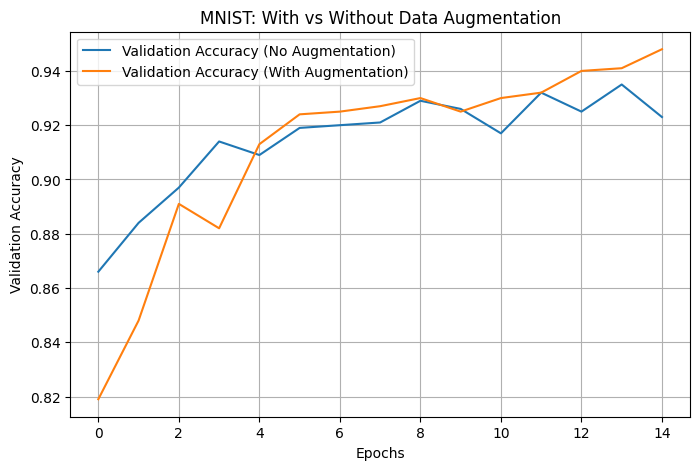

Final Validation Accuracy (No Augmentation): 0.9229999780654907
Final Validation Accuracy (With Augmentation): 0.9480000138282776


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

subset_size = 5000
x_train_small = x_train[:subset_size]
y_train_small = y_train[:subset_size]

x_val = x_test[:1000]
y_val = y_test[:1000]

x_train_small = np.expand_dims(x_train_small, axis=-1)
x_val = np.expand_dims(x_val, axis=-1)

def create_model():
    model = Sequential([
        Flatten(input_shape=(28, 28, 1)),
        Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
        Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

model_no_aug = create_model()

history_no_aug = model_no_aug.fit(
    x_train_small, y_train_small,
    epochs=15,
    batch_size=64,
    validation_data=(x_val, y_val),
    verbose=1
)

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

datagen.fit(x_train_small)

model_aug = create_model()

history_aug = model_aug.fit(
    datagen.flow(x_train_small, y_train_small, batch_size=64),
    epochs=15,
    validation_data=(x_val, y_val),
    verbose=1
)

plt.figure(figsize=(8, 5))

plt.plot(history_no_aug.history['val_accuracy'], label='Validation Accuracy (No Augmentation)')
plt.plot(history_aug.history['val_accuracy'], label='Validation Accuracy (With Augmentation)')

plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('MNIST: With vs Without Data Augmentation')
plt.legend()
plt.grid(True)
plt.show()

print("Final Validation Accuracy (No Augmentation):",
      history_no_aug.history['val_accuracy'][-1])

print("Final Validation Accuracy (With Augmentation):",
      history_aug.history['val_accuracy'][-1])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6220 - loss: 1.6363 - val_accuracy: 0.8790 - val_loss: 0.6385
Epoch 2/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9139 - loss: 0.5195 - val_accuracy: 0.9000 - val_loss: 0.5439
Epoch 3/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9442 - loss: 0.4162 - val_accuracy: 0.9100 - val_loss: 0.4847
Epoch 4/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9555 - loss: 0.3688 - val_accuracy: 0.9070 - val_loss: 0.4625
Epoch 5/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9597 - loss: 0.3375 - val_accuracy: 0.9080 - val_loss: 0.4545
Epoch 6/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9691 - loss: 0.3003 - val_accuracy: 0.9210 - val_loss: 0.4189
Epoch 7/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9762 - loss: 0.2716 - val_accuracy: 0.9220 - val_loss: 0.3976
Epoch 8/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9833 - loss: 0.2548 - val_accuracy: 0.9260 - val_loss: 0.4164
Epo

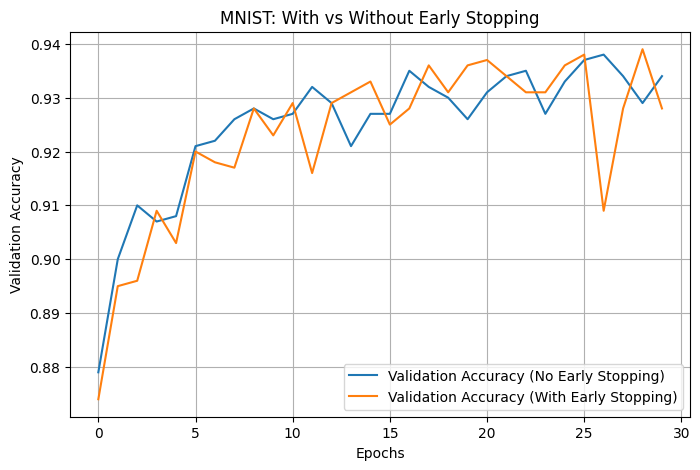

Final Validation Accuracy (No Early Stopping): 0.9340000152587891
Best Validation Accuracy (With Early Stopping): 0.9390000104904175
Epochs used without Early Stopping: 30
Epochs used with Early Stopping: 30


In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

subset_size = 5000
x_train_small = x_train[:subset_size]
y_train_small = y_train[:subset_size]

x_val = x_test[:1000]
y_val = y_test[:1000]

def create_model():
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
        Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

model_no_es = create_model()

history_no_es = model_no_es.fit(
    x_train_small, y_train_small,
    epochs=30,
    batch_size=64,
    validation_data=(x_val, y_val),
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model_es = create_model()

history_es = model_es.fit(
    x_train_small, y_train_small,
    epochs=30,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

plt.figure(figsize=(8, 5))

plt.plot(history_no_es.history['val_accuracy'], label='Validation Accuracy (No Early Stopping)')
plt.plot(history_es.history['val_accuracy'], label='Validation Accuracy (With Early Stopping)')

plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('MNIST: With vs Without Early Stopping')
plt.legend()
plt.grid(True)
plt.show()

print("Final Validation Accuracy (No Early Stopping):",
      history_no_es.history['val_accuracy'][-1])

print("Best Validation Accuracy (With Early Stopping):",
      max(history_es.history['val_accuracy']))

print("Epochs used without Early Stopping:",
      len(history_no_es.history['loss']))

print("Epochs used with Early Stopping:",
      len(history_es.history['loss']))

Epoch 1/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5803 - loss: 1.7022 - val_accuracy: 0.8630 - val_loss: 0.6755
Epoch 2/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9107 - loss: 0.5454 - val_accuracy: 0.8900 - val_loss: 0.5480
Epoch 3/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9314 - loss: 0.4356 - val_accuracy: 0.8990 - val_loss: 0.5250
Epoch 4/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9420 - loss: 0.3942 - val_accuracy: 0.9090 - val_loss: 0.4870
Epoch 5/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9583 - loss: 0.3397 - val_accuracy: 0.9120 - val_loss: 0.4490
Epoch 6/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9610 - loss: 0.3205 - val_accuracy: 0.9130 - val_loss: 0.4316
Epoch 7/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9704 - loss: 0.2881 - val_accuracy: 0.9210 - val_loss: 0.4125
Epoch 8/30
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9796 - loss: 0.2567 - val_accuracy: 0.9210 - val_loss:

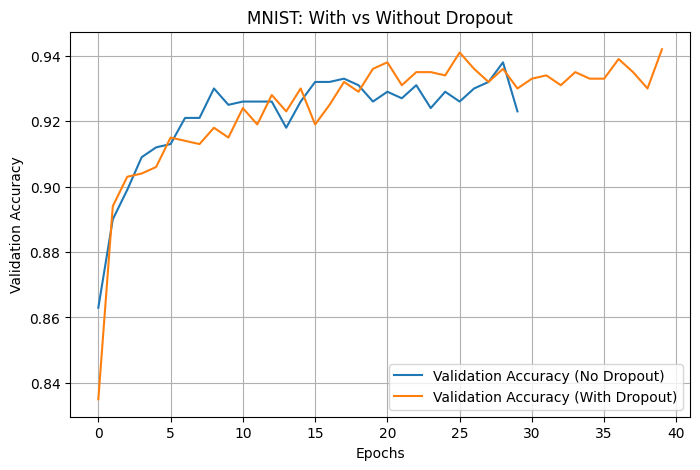

Final Validation Accuracy (No Dropout): 0.9229999780654907
Final Validation Accuracy (With Dropout - Fixed): 0.9419999718666077


In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

subset_size = 5000
x_train_small = x_train[:subset_size]
y_train_small = y_train[:subset_size]

x_val = x_test[:1000]
y_val = y_test[:1000]

def model_without_dropout():
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
        Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

def model_with_dropout_fixed():
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation='relu', kernel_regularizer=l2(0.0005)),
        Dropout(0.2),
        Dense(64, activation='relu', kernel_regularizer=l2(0.0005)),
        Dropout(0.2),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

model_no_dropout = model_without_dropout()

history_no_dropout = model_no_dropout.fit(
    x_train_small, y_train_small,
    epochs=30,
    batch_size=64,
    validation_data=(x_val, y_val),
    verbose=1
)

model_dropout_fixed = model_with_dropout_fixed()

history_dropout_fixed = model_dropout_fixed.fit(
    x_train_small, y_train_small,
    epochs=40,
    batch_size=64,
    validation_data=(x_val, y_val),
    verbose=1
)

plt.figure(figsize=(8, 5))

plt.plot(history_no_dropout.history['val_accuracy'], label='Validation Accuracy (No Dropout)')
plt.plot(history_dropout_fixed.history['val_accuracy'], label='Validation Accuracy (With Dropout)')

plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('MNIST: With vs Without Dropout')
plt.legend()
plt.grid(True)
plt.show()

print("Final Validation Accuracy (No Dropout):",
      history_no_dropout.history['val_accuracy'][-1])

print("Final Validation Accuracy (With Dropout - Fixed):",
      history_dropout_fixed.history['val_accuracy'][-1])

**Result:**
A classifier model to classify MNIST dataset has been successfully implemented and data augmentation, early stopping and dropout regularization techniques has been applied successfully.